In [19]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt


In [20]:
weekly_df = pd.read_csv(
    "prepared_data/weekly_df.csv",
    index_col=0,
    parse_dates=True
)

print("Shape:", weekly_df.shape)

Shape: (1135, 49)


In [21]:
df_hmm = pd.DataFrame(index=weekly_df.index)

# Equity weekly log return (from SP500 level)
df_hmm["sp500_ret_w"] = np.log(weekly_df["SP500"].astype(float)).diff()

# Vol / fear
df_hmm["log_vix"] = np.log(weekly_df["VIX"].astype(float))
df_hmm["rv_30d"]  = weekly_df["RV_30D"].astype(float)

# Credit stress (weekly change)
df_hmm["d_ig_oas"] = weekly_df["IG_OAS_Spread"].astype(float).diff()

# Rates / curve (weekly change in 10Y–2Y slope)
slope_10y2y = (
    weekly_df["US_10Y_Treasury"].astype(float)
    - weekly_df["US_2Y_Treasury"].astype(float)
)
df_hmm["d_slope_10y2y"] = slope_10y2y.diff()

# Financial conditions (level)
df_hmm["nfci"] = weekly_df["NFCI"].astype(float)

print("\nBefore dropna:")
print(df_hmm.info())

df_hmm = df_hmm.dropna()

print("\nAfter dropna:")
print(df_hmm.info())
print("\ndf_hmm head:")
print(df_hmm.head())


Before dropna:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1135 entries, 2004-04-02 to 2025-12-26
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sp500_ret_w    1134 non-null   float64
 1   log_vix        1135 non-null   float64
 2   rv_30d         1135 non-null   float64
 3   d_ig_oas       1134 non-null   float64
 4   d_slope_10y2y  1134 non-null   float64
 5   nfci           1135 non-null   float64
dtypes: float64(6)
memory usage: 62.1 KB
None

After dropna:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1134 entries, 2004-04-09 to 2025-12-26
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sp500_ret_w    1134 non-null   float64
 1   log_vix        1134 non-null   float64
 2   rv_30d         1134 non-null   float64
 3   d_ig_oas       1134 non-null   float64
 4   d_slope_10y2y  1134 non-null   float64
 5   nfci      

In [22]:
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from scipy.stats import multivariate_normal
from scipy.special import logsumexp

# 0) Split: train < 2025
cutoff = pd.Timestamp("2025-01-01")

Z_train = df_hmm.loc[df_hmm.index < cutoff].copy()
Z_test  = df_hmm.loc[df_hmm.index >= cutoff].copy()

print("Train period:", Z_train.index.min(), "->", Z_train.index.max(), " rows:", len(Z_train))
print("Test  period:", Z_test.index.min(),  "->", Z_test.index.max(),  " rows:", len(Z_test))

# 1) Standardize using TRAIN only
scaler = StandardScaler()
Z_train_std = scaler.fit_transform(Z_train.values)
Z_test_std  = scaler.transform(Z_test.values)

# 2) Fit Gaussian HMM on TRAIN only
K = 3
hmm = GaussianHMM(
    n_components=K,
    covariance_type="full",
    n_iter=500,
    random_state=42
)
hmm.fit(Z_train_std)

A = hmm.transmat_.copy()        # transition matrix
pi = hmm.startprob_.copy()      # initial state probs

print("\nFitted HMM")
print("startprob_:", np.round(pi, 3))
print("diag(transmat_):", np.round(np.diag(A), 3))

# 3) FILTERED probabilities (forward recursion) - no lookahead
def emission_logprob_gaussian(hmm_model, X):
    """Return log b_t(k) = log p(x_t | state=k) for all t,k."""
    means = hmm_model.means_
    covs  = hmm_model.covars_
    K, d = means.shape

    logB = np.zeros((X.shape[0], K))
    # build per-state distributions
    rvs = [
        multivariate_normal(mean=means[k], cov=covs[k], allow_singular=True)
        for k in range(K)
    ]
    for k in range(K):
        logB[:, k] = rvs[k].logpdf(X)
    return logB

def filtered_probs(hmm_model, X, init_alpha=None):
    logA = np.log(hmm_model.transmat_ + 1e-300)
    if init_alpha is None:
        log_alpha = np.log(hmm_model.startprob_ + 1e-300)
    else:
        log_alpha = np.log(init_alpha + 1e-300)

    logB = emission_logprob_gaussian(hmm_model, X)

    T, K = logB.shape
    out = np.zeros((T, K))

    # t=0
    log_alpha = log_alpha + logB[0]
    log_alpha = log_alpha - logsumexp(log_alpha)  # normalize
    out[0] = np.exp(log_alpha)

    # t=1..T-1
    for t in range(1, T):
        # log_alpha_j = logB[t,j] + logsumexp_i(log_alpha_prev_i + logA_i,j)
        log_alpha = logB[t] + logsumexp(log_alpha[:, None] + logA, axis=0)
        log_alpha = log_alpha - logsumexp(log_alpha)  # normalize
        out[t] = np.exp(log_alpha)

    return out

# Train filtered probs
P_train = filtered_probs(hmm, Z_train_std)

# Test filtered probs, initialized from last train filtered state
init_alpha_test = P_train[-1]
P_test = filtered_probs(hmm, Z_test_std, init_alpha=init_alpha_test)

# 4) Build regime feature DataFrames
cols_prob = [f"prob_state_{k}" for k in range(K)]

df_regime_train = pd.DataFrame(P_train, index=Z_train.index, columns=cols_prob)
df_regime_test  = pd.DataFrame(P_test,  index=Z_test.index,  columns=cols_prob)

# More variables:
def entropy(p):
    p = np.clip(p, 1e-12, 1.0)
    return -(p * np.log(p)).sum(axis=1)

def persistence(p, A):
    # expected probability of staying in same state next step
    return (p * np.diag(A)).sum(axis=1)

df_regime_train["regime_entropy"] = entropy(P_train)
df_regime_test["regime_entropy"]  = entropy(P_test)

df_regime_train["regime_persist"] = persistence(P_train, A)
df_regime_test["regime_persist"]  = persistence(P_test, A)

df_regime_train["regime_label"] = np.argmax(P_train, axis=1)
df_regime_test["regime_label"]  = np.argmax(P_test, axis=1)

print("\nRegime features (train) head:")
print(df_regime_train.head())
print("\nRegime features (test) head:")
print(df_regime_test.head())

# If you want one combined df aligned to df_hmm index:
df_regime_all = pd.concat([df_regime_train, df_regime_test], axis=0).sort_index()
print("\nCombined regime df shape:", df_regime_all.shape)

Train period: 2004-04-09 00:00:00 -> 2024-12-27 00:00:00  rows: 1082
Test  period: 2025-01-03 00:00:00 -> 2025-12-26 00:00:00  rows: 52

Fitted HMM
startprob_: [1. 0. 0.]
diag(transmat_): [0.978 0.961 0.961]

Regime features (train) head:
            prob_state_0  prob_state_1   prob_state_2  regime_entropy  \
2004-04-09      1.000000  3.760626e-38  5.479614e-257    5.526204e-11   
2004-04-16      0.999707  2.927999e-04   4.566370e-07    2.682106e-03   
2004-04-23      0.999688  3.111831e-04   1.118259e-06    2.840420e-03   
2004-04-30      0.998560  1.436607e-03   3.733874e-06    1.088924e-02   
2004-05-07      0.999749  2.502650e-04   5.798878e-07    2.334586e-03   

            regime_persist  regime_label  
2004-04-09        0.978293             0  
2004-04-16        0.978288             0  
2004-04-23        0.978288             0  
2004-04-30        0.978269             0  
2004-05-07        0.978289             0  

Regime features (test) head:
            prob_state_0  prob_sta

In [23]:
# ============================================================
# BLOCK 0 — Map HMM states -> names using TRAIN ONLY
# ============================================================

# 1) Prob columns + K
prob_cols = [f"prob_state_{k}" for k in range(K)]

# 2) Align index and restrict to TRAIN
idx_all = df_hmm.index.intersection(df_regime_all.index).sort_values()
idx_train = idx_all[idx_all < cutoff]

# 3) Get labels on TRAIN
labels_train = df_regime_all.loc[idx_train, "regime_label"].astype(int)

# 4) Build stress score on TRAIN only
stress_cols = ["log_vix", "rv_30d", "nfci", "sp500_ret_w"]

tmp = df_hmm.loc[idx_train, stress_cols].copy()
tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna()

# align labels to rows that survived dropna
labels_train = labels_train.loc[tmp.index]

# z-score across TRAIN (units-free)
Z = (tmp - tmp.mean()) / tmp.std(ddof=0)

# higher VIX/RV/NFCI + more negative returns => more stress
stress_score = Z["log_vix"] + Z["rv_30d"] + Z["nfci"] + (-Z["sp500_ret_w"])

# 5) Rank states by mean stress (TRAIN only)
state_stress = stress_score.groupby(labels_train).mean().sort_values()
state_rank = list(state_stress.index)  # calm -> stressed

# 6) Assign names by rank
name_by_rank = ["Calm", "Volatile", "Crisis"]

state_name_map = {int(state_rank[i]): name_by_rank[i] for i in range(K)}

print("TRAIN-only state stress ranking (low -> high):")
print(state_stress)
print("\nTRAIN-only State -> Name mapping:")
print(state_name_map)

TRAIN-only state stress ranking (low -> high):
regime_label
0   -1.765257
1   -0.055335
2    4.617368
dtype: float64

TRAIN-only State -> Name mapping:
{0: 'Calm', 1: 'Volatile', 2: 'Crisis'}


Latest: 2025-12-26 | Calm (state 0) | probs: 0.97, 0.03, 0.00


C:\Users\jmesc\AppData\Local\Temp\ipykernel_28508\4093188643.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", K)


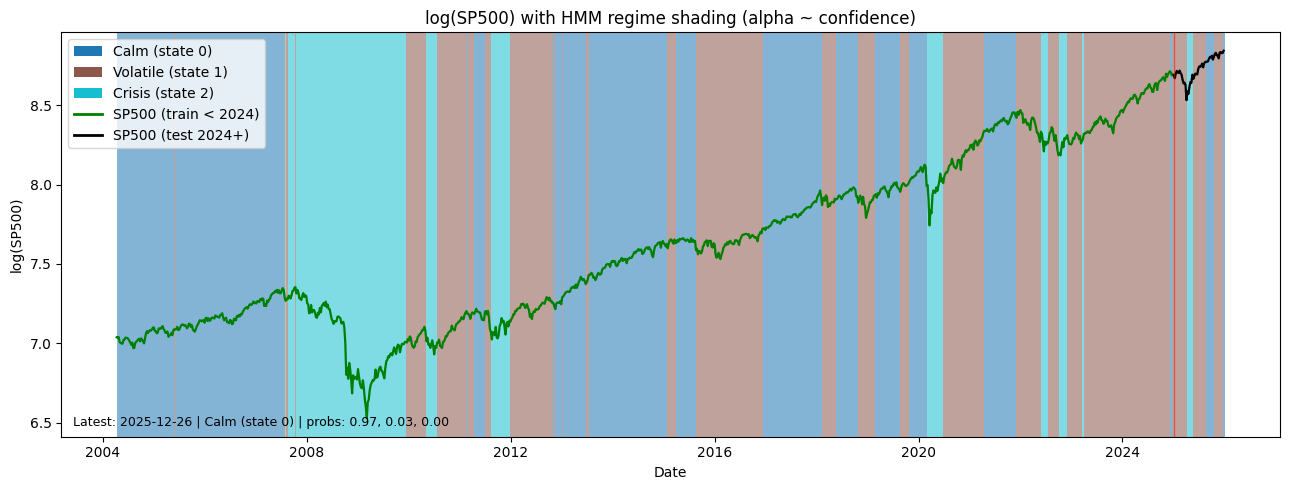

In [24]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ============================================================
# BLOCK 1 — Plot log(SP500) 
# ============================================================

prob_cols = [f"prob_state_{k}" for k in range(K)]

idx = weekly_df.index.intersection(df_regime_all.index).sort_values()
sp_level = weekly_df.loc[idx, "SP500"].astype(float)
sp_log = np.log(sp_level)

probs = df_regime_all.loc[idx, prob_cols].astype(float)

# Labels used only for shading segments (fine to use all dates)
labels = df_regime_all.loc[idx, "regime_label"].astype(int).values

maxprob = probs.values.max(axis=1)

# contiguous segments
labels = np.asarray(labels)
segments = []
start = 0
for i in range(1, len(idx)):
    if labels[i] != labels[i-1]:
        segments.append((start, i-1, int(labels[i-1])))
        start = i
segments.append((start, len(idx)-1, int(labels[-1])))

# right-edge shading step
step = pd.Timedelta(days=7)

fig, ax = plt.subplots(figsize=(13, 5))
cmap = plt.cm.get_cmap("tab10", K)

# shaded regimes (alpha ~ confidence)
for s, e, k in segments:
    alpha = float(np.clip(np.nanmean(maxprob[s:e+1]), 0.12, 0.55))
    ax.axvspan(idx[s], idx[e] + step, color=cmap(k), alpha=alpha, lw=0)

# SP500 log line: different color from 2024 onwards
mask_train = idx < cutoff
mask_test  = idx >= cutoff
ax.plot(idx[mask_train], sp_log.loc[idx[mask_train]].values, lw=1.6, color="green", label="SP500 (train period)")
ax.plot(idx[mask_test],  sp_log.loc[idx[mask_test]].values,  lw=1.6, color="black", label="SP500 (test period)")

ax.axvline(cutoff, color="red", lw=1.0, alpha=0.5)

ax.set_title("log(SP500) with HMM regime shading (alpha ~ confidence)")
ax.set_xlabel("Date")
ax.set_ylabel("log(SP500)")

# legend: regimes + train/test
handles = []
for k in range(K):
    name = state_name_map[k]
    handles.append(Patch(facecolor=cmap(k), edgecolor="none", label=f"{name} (state {k})"))

handles += [
    Line2D([0], [0], color="green", lw=2, label="SP500 (train < 2024)"),
    Line2D([0], [0], color="black", lw=2, label="SP500 (test 2024+)"),
]
ax.legend(handles=handles, loc="upper left", frameon=True)

# latest text
last_date = idx[-1]
last_probs = probs.loc[last_date].values
last_state = int(np.argmax(last_probs))
last_name = state_name_map.get(last_state, f"State {last_state}")

txt = (
    f"Latest: {last_date.date()} | {last_name} (state {last_state}) | probs: "
    + ", ".join([f"{p:.2f}" for p in last_probs])
)
print(txt)
ax.text(0.01, 0.02, txt, transform=ax.transAxes, fontsize=9, va="bottom")

plt.tight_layout()
plt.show()

### Load vars

In [25]:
import pandas as pd

path_in = "prepared_data/reduced_vars.csv"
path_out = "prepared_data/reduced_vars_with_hmm.csv"

# Cargar reduced vars
df_red = pd.read_csv(path_in, index_col=0, parse_dates=True)

# Columnas HMM
hmm_cols = [c for c in df_regime_all.columns if c.startswith("prob_state_")]
extra_cols = ["regime_entropy", "regime_persist", "regime_label"]

# Unir
df_final = df_red.join(df_regime_all[hmm_cols + extra_cols], how="left")

# Limpiar filas sin probs HMM
df_final = df_final.dropna(subset=hmm_cols)

# Guardar
df_final.to_csv(path_out)

print("Saved:", path_out)

Saved: prepared_data/reduced_vars_with_hmm.csv
